In [20]:
!pip install sentence-transformers seaborn matplotlib

In [21]:
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
sentences = [
    #Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",


    #Cooking
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "The recipe includes fresh vegetables and spices",

    #Cybersecurity
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures data security over networks",
    "Phishing attacks trick users into revealing sensitive information",
    "Firewalls prevent unauthorized access to systems",
    ]

In [23]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
similarity_matrix = cosine_similarity(embeddings)

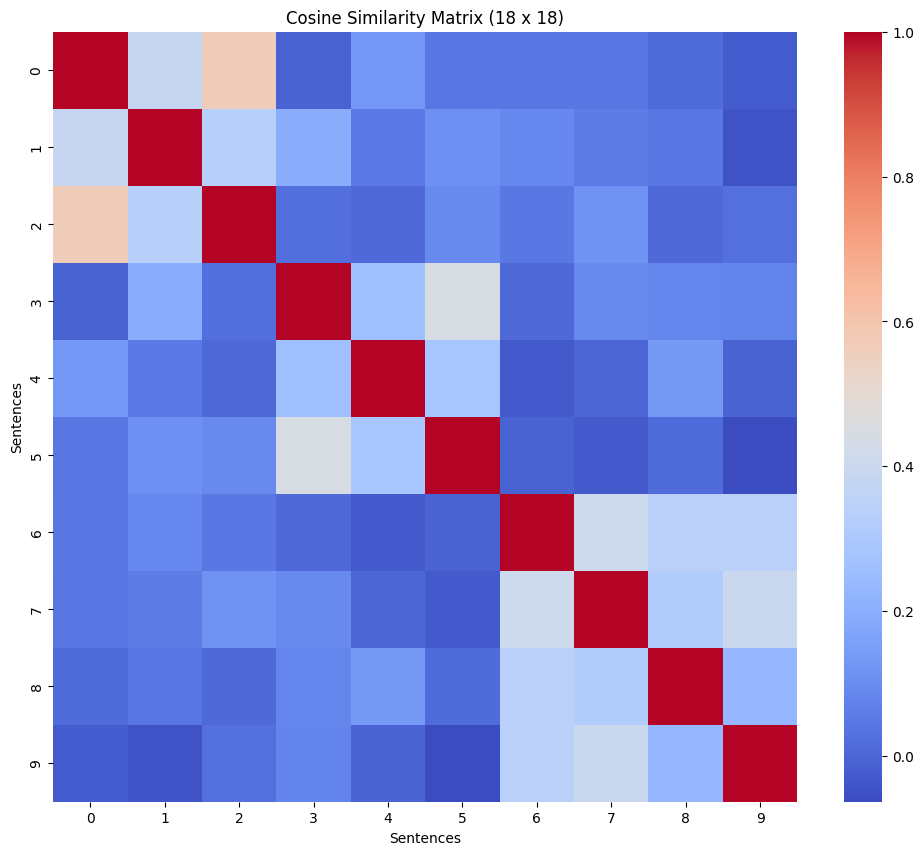

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Matrix (18 x 18)")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.show()

In [26]:
query = "The bowler took three wickets in one over"

In [27]:
query_embedding = model.encode([query])

In [28]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [29]:
top_indices = similarities.argsort()[-2:][::-1]

for i in top_indices:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity Score: {similarities[i]:.4f}")
    print()

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414

